# 11 —  Comprehensive Exploratory Data Analysis

**Inputs:**
- `data/interim/weather_daily_clean.csv` — 5 cities × daily weather, 2020-01-01 → 2026-04-18
- `data/interim/weather_hourly_clean.csv` — hourly weather
- `data/interim/ndvi.csv` — NDVI vegetation index (16 cities)
- `data/interim/firms.csv` — NASA FIRMS wildfire hotspots
- `data/interim/lightning.csv` — lightning climatology
- `data/interim/cities_reference.csv` — city lat/lon reference

**Goals:**
1. Comprehensive descriptive statistics for all variables across all cities
2. Visualise distributions, trends, and seasonal patterns
3. Compare weather patterns across the 5 study cities
4. Identify patterns worth investigating with formal statistical tests

---

## 0. Setup

In [2]:
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal, shapiro, spearmanr

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 180)
pd.set_option('display.float_format', '{:.3f}'.format)

# ── Aesthetics ─────────────────────────────────────────────────────────────
CITY_PALETTE = {
    'Baku':     '#E63946',
    'Ganja':    '#2196F3',
    'Guba':     '#4CAF50',
    'Lankaran': '#FF9800',
    'Zaqatala': '#9C27B0',
}
CITIES = list(CITY_PALETTE.keys())

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
})

# ── Paths ───────────────────────────────────────────────────────────────────
# Find project root and data directory
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'data').is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

INTERIM = PROJECT_ROOT / 'data' / 'interim'

print('Project root:', PROJECT_ROOT)
print('INTERIM dir:', INTERIM)
print('Available files:', [f.name for f in INTERIM.iterdir() if f.suffix == '.csv'])

Project root: c:\Users\pc\Downloads\ARIAN - Copy
INTERIM dir: c:\Users\pc\Downloads\ARIAN - Copy\data\interim
Available files: ['cities_reference.csv', 'firms.csv', 'landcover_at_cities.csv', 'lightning.csv', 'multi_horizon_summary.csv', 'ndvi.csv', 'population.csv', 'roads.csv', 'summary.csv', 'weather_daily_clean.csv', 'weather_daily_raw.csv', 'weather_forecast.csv', 'weather_hourly_clean.csv', 'weather_hourly_raw.csv']


## 1. Load All Datasets

In [3]:
# ── Daily weather (primary analysis frame) ──────────────────────────────────
daily = pd.read_csv(INTERIM / 'weather_daily_clean.csv', parse_dates=['date'])
if daily['date'].dt.tz is not None:
    daily['date'] = daily['date'].dt.tz_localize(None)

# Derived time columns
daily['year']    = daily['date'].dt.year
daily['month']   = daily['date'].dt.month
daily['doy']     = daily['date'].dt.dayofyear
daily['season']  = daily['month'].map({
    12:'Winter', 1:'Winter', 2:'Winter',
    3:'Spring',  4:'Spring',  5:'Spring',
    6:'Summer',  7:'Summer',  8:'Summer',
    9:'Autumn', 10:'Autumn', 11:'Autumn',
})
daily['temp_range'] = daily['temperature_2m_max'] - daily['temperature_2m_min']

# ── Supporting datasets ─────────────────────────────────────────────────────
ndvi      = pd.read_csv(INTERIM / 'ndvi.csv', parse_dates=['date'])
if ndvi['date'].dt.tz is not None:
    ndvi['date'] = ndvi['date'].dt.tz_localize(None)

firms     = pd.read_csv(INTERIM / 'firms.csv', parse_dates=['acq_date'])
lightning = pd.read_csv(INTERIM / 'lightning.csv')
cities    = pd.read_csv(INTERIM / 'cities_reference.csv')

# ── Summary ─────────────────────────────────────────────────────────────────
print('=== DAILY WEATHER ===')
print(f'  Shape      : {daily.shape}')
print(f'  Cities     : {sorted(daily["City"].unique())}')
print(f'  Date range : {daily["date"].min().date()}  →  {daily["date"].max().date()}')
print(f'  Variables  : {daily.shape[1] - 4} weather columns  (no missing values)')

print('\n=== NDVI ===')
print(f'  Shape      : {ndvi.shape}')
print(f'  Cities     : {ndvi["City"].nunique()} cities')

print('\n=== FIRMS (wildfire hotspots) ===')
print(f'  Shape      : {firms.shape}')
print(f'  Date range : {firms["acq_date"].min()}  →  {firms["acq_date"].max()}')

print('\n=== LIGHTNING ===')
print(f'  Shape      : {lightning.shape}')
print(f'  Years      : {sorted(lightning["year"].unique())}')

=== DAILY WEATHER ===
  Shape      : (11500, 29)
  Cities     : ['Baku', 'Ganja', 'Guba', 'Lankaran', 'Zaqatala']
  Date range : 2020-01-01  →  2026-04-18
  Variables  : 25 weather columns  (no missing values)

=== NDVI ===
  Shape      : (2304, 3)
  Cities     : 16 cities

=== FIRMS (wildfire hotspots) ===
  Shape      : (21218, 16)
  Date range : 2020-01-01 00:00:00  →  2024-12-31 00:00:00

=== LIGHTNING ===
  Shape      : (366619, 5)
  Years      : [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


## 2. Comprehensive Descriptive Statistics

### 2.1 Global summary — all variables across all cities

In [4]:
WEATHER_VARS = [
    'temperature_2m_mean', 'temperature_2m_min', 'temperature_2m_max', 'temp_range',
    'relative_humidity_2m_mean', 'dew_point_2m_mean',
    'precipitation_sum', 'rain_sum',
    'cloud_cover_mean', 'vapour_pressure_deficit_mean',
    'wind_speed_10m_mean', 'wind_speed_10m_max', 'wind_gusts_10m_max',
    'soil_temperature_0_to_7cm_mean', 'soil_temperature_28_to_100cm_mean',
    'sunshine_duration_sum', 'shortwave_radiation_mean',
]

VAR_UNITS = {
    'temperature_2m_mean'              : '°C',
    'temperature_2m_min'               : '°C',
    'temperature_2m_max'               : '°C',
    'temp_range'                       : '°C',
    'relative_humidity_2m_mean'        : '%',
    'dew_point_2m_mean'                : '°C',
    'precipitation_sum'                : 'mm',
    'rain_sum'                         : 'mm',
    'cloud_cover_mean'                 : '%',
    'vapour_pressure_deficit_mean'     : 'kPa',
    'wind_speed_10m_mean'              : 'km/h',
    'wind_speed_10m_max'               : 'km/h',
    'wind_gusts_10m_max'               : 'km/h',
    'soil_temperature_0_to_7cm_mean'   : '°C',
    'soil_temperature_28_to_100cm_mean': '°C',
    'sunshine_duration_sum'            : 's/day',
    'shortwave_radiation_mean'         : 'W/m²',
}

# Extended describe: add skewness + kurtosis
desc = daily[WEATHER_VARS].describe().T
desc['skewness'] = daily[WEATHER_VARS].skew()
desc['kurtosis'] = daily[WEATHER_VARS].kurtosis()
desc['unit']     = desc.index.map(VAR_UNITS)
desc = desc[['unit', 'count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'skewness', 'kurtosis']]
print('Global Descriptive Statistics — all cities combined')
desc

Global Descriptive Statistics — all cities combined


,unit,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
temperature_2m_mean,°C,11500.000,14.073,8.677,-12.981,6.908,13.735,21.664,32.210,0.006,-1.018
temperature_2m_min,°C,11500.000,10.309,8.162,-15.700,3.722,10.050,17.500,26.500,-0.061,-0.950
temperature_2m_max,°C,11500.000,18.123,9.365,-10.950,10.417,17.850,26.072,40.050,0.024,-0.952
temp_range,°C,11500.000,7.814,3.282,0.600,5.450,7.700,10.000,24.850,0.300,-0.077
relative_humidity_2m_mean,%,11500.000,69.383,14.827,13.284,59.613,70.373,80.937,99.226,-0.428,-0.266
dew_point_2m_mean,°C,11500.000,7.818,7.394,-24.410,2.421,8.381,13.652,25.003,-0.310,-0.470
precipitation_sum,mm,11500.000,1.879,5.654,0.000,0.000,0.000,1.000,143.900,7.026,83.567
rain_sum,mm,11500.000,1.712,5.472,0.000,0.000,0.000,0.800,143.900,7.473,93.963
cloud_cover_mean,%,11500.000,50.455,33.243,0.000,20.458,49.583,81.625,100.000,0.033,-1.344
vapour_pressure_deficit_mean,kPa,11500.000,0.678,0.619,0.006,0.231,0.461,0.935,3.579,1.556,2.298


### 2.2 Per-city summary — key variables

In [5]:
KEY_VARS = [
    'temperature_2m_mean', 'temp_range',
    'precipitation_sum', 'relative_humidity_2m_mean',
    'wind_speed_10m_mean', 'sunshine_duration_sum',
    'vapour_pressure_deficit_mean',
]

city_stats = (
    daily.groupby('City')[KEY_VARS]
    .agg(['mean', 'std', 'min', 'max'])
    .round(2)
)
print('Per-city descriptive statistics')
city_stats

Per-city descriptive statistics


temperature_2m_mean                      temp_range                    precipitation_sum                     relative_humidity_2m_mean                       \
                        mean   std     min    max       mean   std   min    max              mean   std   min     max                      mean    std    min    max   
City                                                                                                                                                                   
Baku                  15.320 8.350  -3.300 32.210      7.340 3.300 0.750 18.450             0.910 3.190 0.000  67.900                    72.590 11.750 31.230 97.250   
Ganja                 14.260 8.950  -3.640 31.610      9.200 3.100 1.000 18.100             0.900 2.830 0.000  50.400                    62.190 15.060 21.370 95.780   
Guba                  11.320 9.160 -12.980 30.550      8.770 3.770 0.800 24.850             1.790 4.480 0.000  92.000                    69.850 16.100 13.280 99.230   
Lankaran              16.020 7.660  -1.240 30.050      6.030 2.490 0.600 16.200             2.730 7.420 0.000 143.900                    76.870 10.980 39.610 99.050   
Zaqatala              13.450 8.420  -7.810 30.130      7.740 2.580 1.300 16.200             3.070 7.910 0.000  92.100                    65.410 14.850 19.260 98.320   

         wind_speed_10m_mean                    sunshine_duration_sum                           vapour_pressure_deficit_mean                    
                        mean   std   min    max                  mean       std   min       max                         mean   std   min   max  
City                                                                                                                                            
Baku                  15.690 7.060 2.330 46.510             31502.560 14802.160 0.000 48942.350                        0.690 0.610 0.030 3.540  
Ganja                  8.050 3.650 1.980 35.820             33499.490 13012.120 0.000 50400.000                        0.870 0.760 0.030 3.500  
Guba                   7.080 2.330 1.890 23.120             29722.840 15702.730 0.000 50880.790                        0.620 0.620 0.010 3.580  
Lankaran               7.970 3.020 1.760 22.730             28602.150 16335.460 0.000 49010.860                        0.540 0.440 0.010 2.370  
Zaqatala               4.480 1.340 1.160 15.810             34065.140 13312.690 0.000 50447.490                        0.680 0.570 0.010 3.140

In [6]:
# Seasonal breakdown per city
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
seasonal = (
    daily.groupby(['City', 'season'])['temperature_2m_mean']
    .agg(['mean', 'std'])
    .round(2)
    .unstack('season')
    .reindex(columns=pd.MultiIndex.from_product([['mean','std'], season_order]))
)
print('Seasonal mean / std temperature by city')
seasonal

Seasonal mean / std temperature by city


mean                         std                     
         Winter Spring Summer Autumn Winter Spring Summer Autumn
City                                                            
Baku      6.000 13.000 26.250 17.070  2.750  5.020  2.560  5.050
Ganja     3.990 13.170 25.710 15.170  3.070  5.730  2.920  5.590
Guba      1.190 10.020 22.930 12.150  3.970  6.230  3.140  5.620
Lankaran  7.260 14.160 25.790 17.850  2.900  4.720  2.060  4.580
Zaqatala  3.960 12.310 23.940 14.540  3.580  5.540  3.020  5.350

### 2.3 Missing values audit

In [7]:
miss = daily[WEATHER_VARS].isna().mean() * 100
print('Missing value % after cleaning:')
print(miss.to_string())
print(f'\n✓ All {len(miss)} weather variables have 0 % missing after cleaning pipeline.')

Missing value % after cleaning:
temperature_2m_mean                 0.000
temperature_2m_min                  0.000
temperature_2m_max                  0.000
temp_range                          0.000
relative_humidity_2m_mean           0.000
dew_point_2m_mean                   0.000
precipitation_sum                   0.000
rain_sum                            0.000
cloud_cover_mean                    0.000
vapour_pressure_deficit_mean        0.000
wind_speed_10m_mean                 0.000
wind_speed_10m_max                  0.000
wind_gusts_10m_max                  0.000
soil_temperature_0_to_7cm_mean      0.000
soil_temperature_28_to_100cm_mean   0.000
sunshine_duration_sum               0.000
shortwave_radiation_mean            0.000

✓ All 17 weather variables have 0 % missing after cleaning pipeline.


## 3. Distribution Analysis

### 3.1 Histograms + KDE — core variables

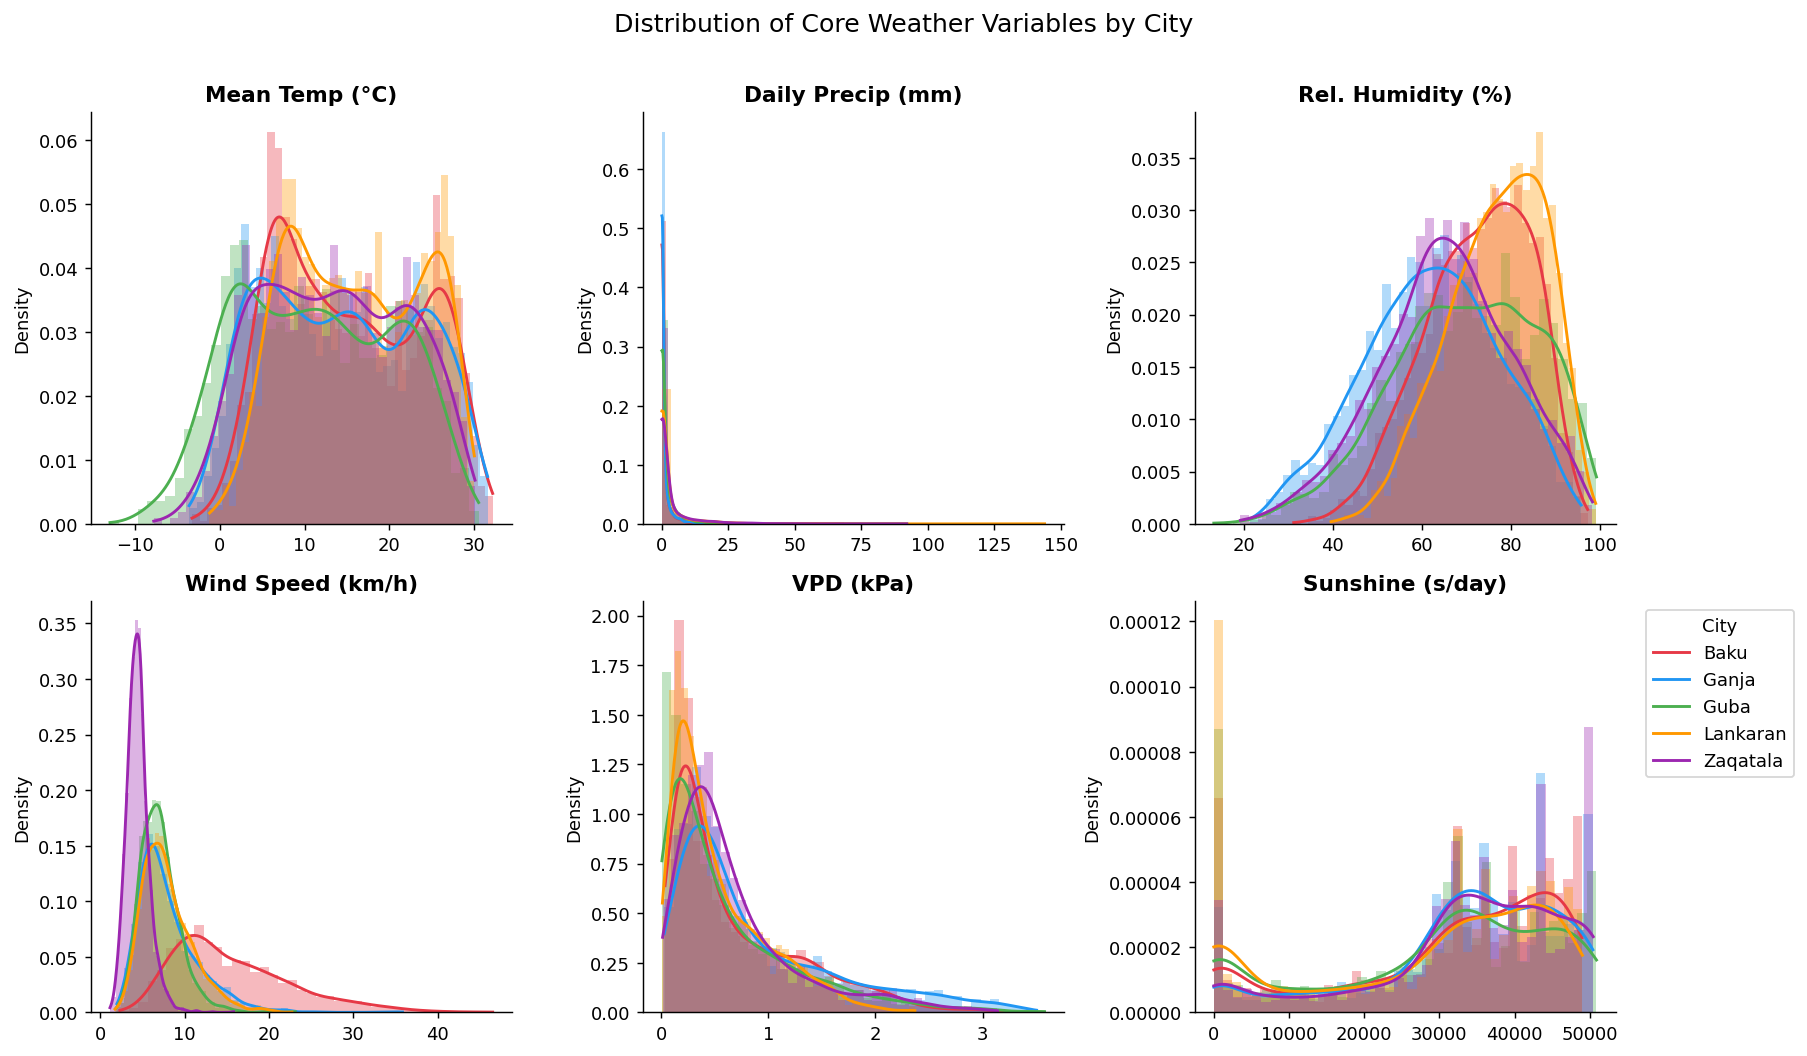

In [8]:
DIST_VARS = [
    ('temperature_2m_mean',          'Mean Temp (°C)'),
    ('precipitation_sum',            'Daily Precip (mm)'),
    ('relative_humidity_2m_mean',    'Rel. Humidity (%)'),
    ('wind_speed_10m_mean',          'Wind Speed (km/h)'),
    ('vapour_pressure_deficit_mean', 'VPD (kPa)'),
    ('sunshine_duration_sum',        'Sunshine (s/day)'),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flat

for ax, (col, label) in zip(axes, DIST_VARS):
    for city, color in CITY_PALETTE.items():
        vals = daily.loc[daily['City'] == city, col].dropna()
        ax.hist(vals, bins=40, alpha=0.35, color=color, density=True)
        try:
            kde_x = np.linspace(vals.min(), vals.max(), 300)
            kde   = stats.gaussian_kde(vals)(kde_x)
            ax.plot(kde_x, kde, color=color, lw=1.6, label=city)
        except Exception:
            pass
    ax.set_title(label)
    ax.set_ylabel('Density')

axes[-1].legend(title='City', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.suptitle('Distribution of Core Weather Variables by City', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 3.2 Box plots — all seasons

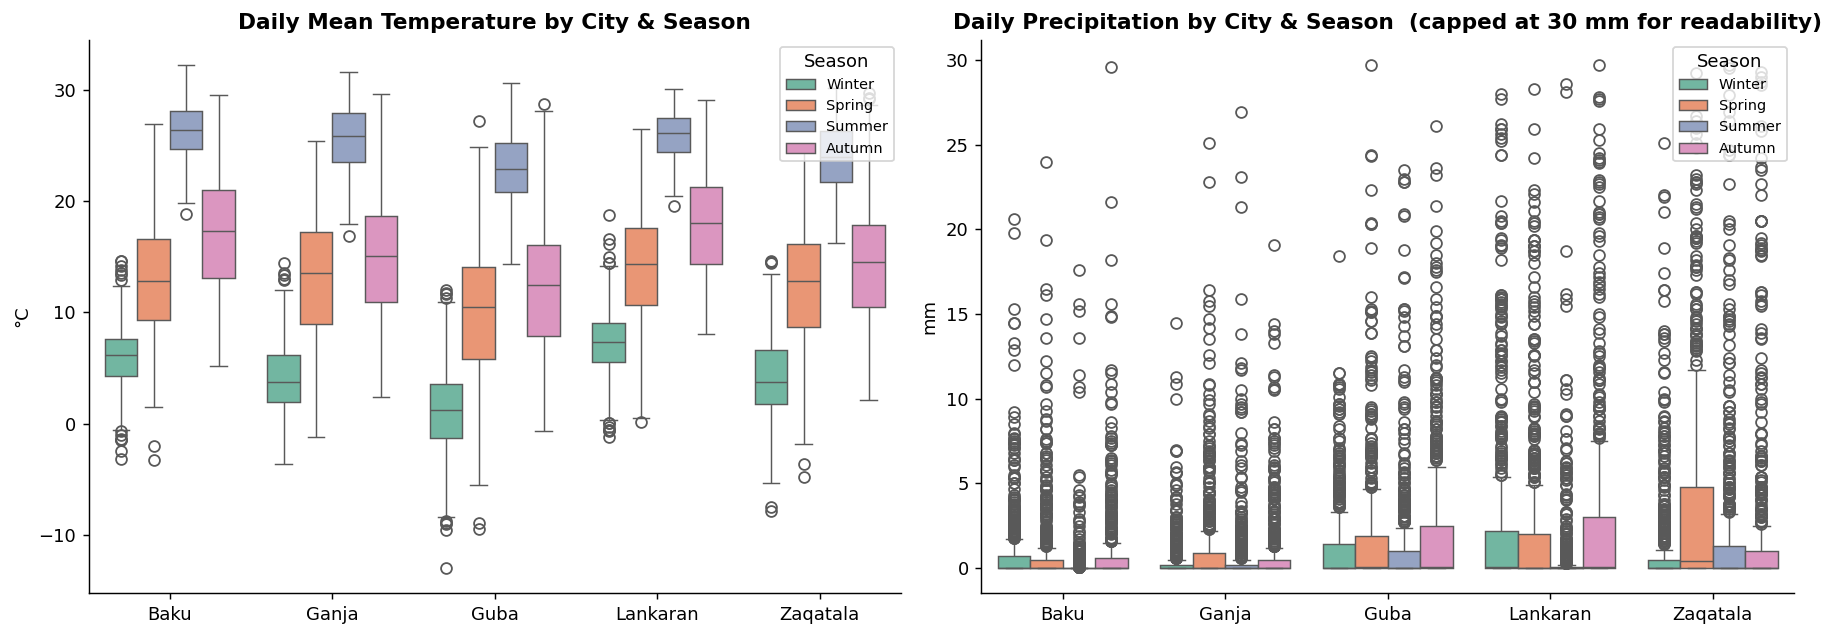

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Temperature by city + season
ax = axes[0]
sns.boxplot(
    data=daily, x='City', y='temperature_2m_mean',
    hue='season', hue_order=season_order,
    palette='Set2', ax=ax, linewidth=0.8,
    order=CITIES,
)
ax.set_title('Daily Mean Temperature by City & Season')
ax.set_xlabel(''); ax.set_ylabel('°C')
ax.legend(title='Season', loc='upper right', fontsize=8)

# Precipitation by city + season
ax = axes[1]
sns.boxplot(
    data=daily[daily['precipitation_sum'] < 30],
    x='City', y='precipitation_sum',
    hue='season', hue_order=season_order,
    palette='Set2', ax=ax, linewidth=0.8,
    order=CITIES,
)
ax.set_title('Daily Precipitation by City & Season  (capped at 30 mm for readability)')
ax.set_xlabel(''); ax.set_ylabel('mm')
ax.legend(title='Season', loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

### 3.3 Normality check — Shapiro-Wilk (sampled)

In [10]:
rng = np.random.default_rng(42)
SW_VARS = ['temperature_2m_mean', 'precipitation_sum', 'wind_speed_10m_mean',
           'relative_humidity_2m_mean', 'sunshine_duration_sum']
records = []
for city in CITIES:
    sub = daily[daily['City'] == city]
    for var in SW_VARS:
        vals = sub[var].dropna().values
        sample = rng.choice(vals, size=min(500, len(vals)), replace=False)
        stat, p = shapiro(sample)
        records.append({
            'City': city, 'Variable': var,
            'W': round(stat, 4), 'p-value': round(p, 4),
            'Normal (α=0.05)': 'Yes' if p > 0.05 else 'No',
        })

sw_df = pd.DataFrame(records)
print('Shapiro-Wilk normality test (n=500 sample per city per variable)')
sw_df.pivot(index='Variable', columns='City', values='Normal (α=0.05)')

Shapiro-Wilk normality test (n=500 sample per city per variable)


City,Baku,Ganja,Guba,Lankaran,Zaqatala
Variable,,,,,
precipitation_sum,No,No,No,No,No
relative_humidity_2m_mean,No,No,No,No,No
sunshine_duration_sum,No,No,No,No,No
temperature_2m_mean,No,No,No,No,No
wind_speed_10m_mean,No,No,No,No,No


## 4. Temporal Trends

### 4.1 Annual mean temperature trend — all cities

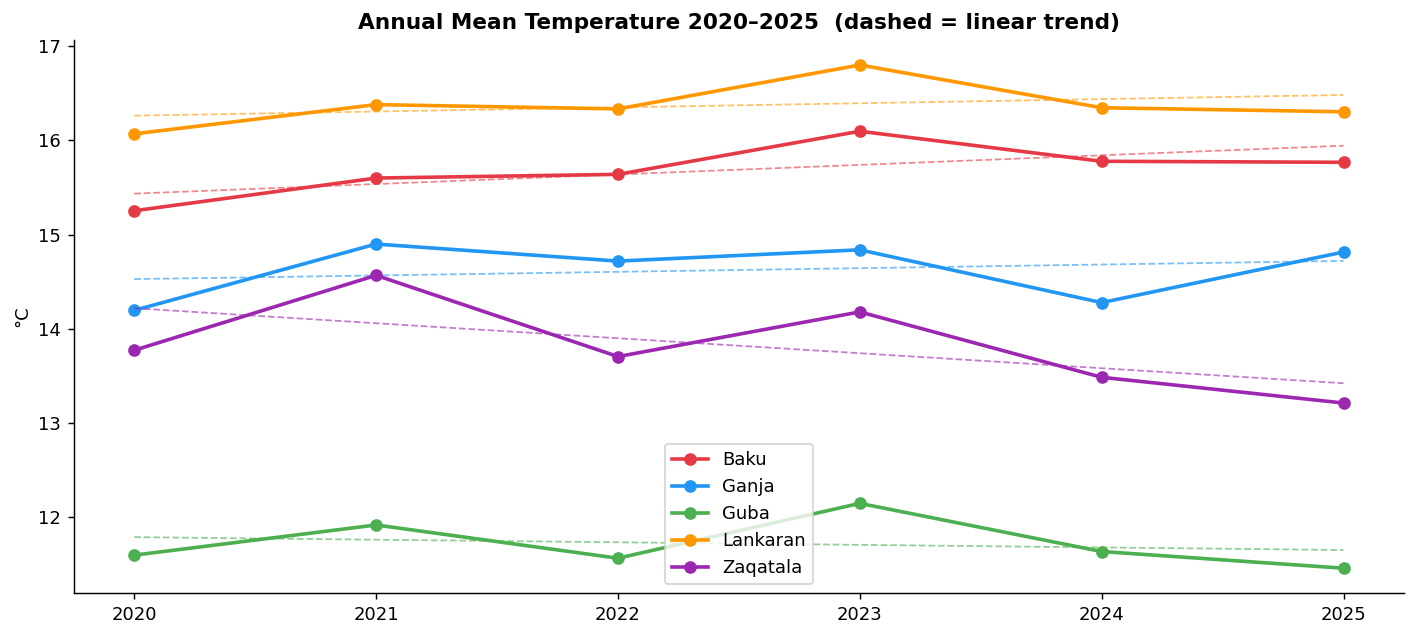


Temperature trend slopes (°C / year):
  Baku          slope=+0.102  r²=0.476  p=0.129
  Ganja         slope=+0.039  r²=0.056  p=0.653
  Guba          slope=-0.027  r²=0.039  p=0.708
  Lankaran      slope=+0.044  r²=0.120  p=0.501
  Zaqatala      slope=-0.159  r²=0.375  p=0.197


In [11]:
annual = daily.groupby(['City', 'year'])['temperature_2m_mean'].mean().reset_index()
# Drop partial 2026
annual = annual[annual['year'] < 2026]

fig, ax = plt.subplots(figsize=(11, 5))
for city, color in CITY_PALETTE.items():
    sub = annual[annual['City'] == city]
    ax.plot(sub['year'], sub['temperature_2m_mean'], 'o-', color=color,
            label=city, lw=2, ms=6)
    # trend line
    if len(sub) > 2:
        z = np.polyfit(sub['year'], sub['temperature_2m_mean'], 1)
        ax.plot(sub['year'], np.poly1d(z)(sub['year']), '--', color=color, lw=1, alpha=0.6)

ax.set_title('Annual Mean Temperature 2020–2025  (dashed = linear trend)')
ax.set_ylabel('°C'); ax.set_xlabel('')
ax.legend()
plt.tight_layout()
plt.show()

# Trend slopes
print('\nTemperature trend slopes (°C / year):')
for city in CITIES:
    sub = annual[annual['City'] == city]
    slope, intercept, r, p, se = stats.linregress(sub['year'], sub['temperature_2m_mean'])
    print(f'  {city:<12}  slope={slope:+.3f}  r²={r**2:.3f}  p={p:.3f}')

### 4.2 Annual total precipitation trend

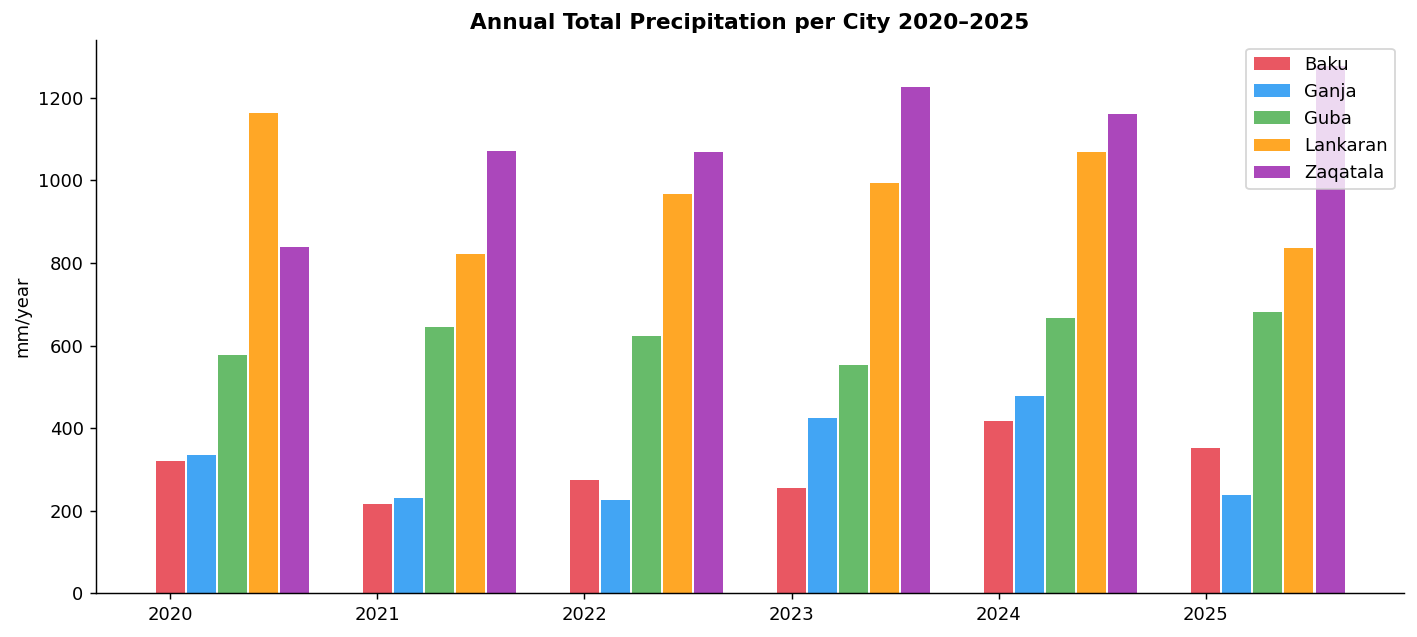

In [12]:
annual_precip = daily[daily['year'] < 2026].groupby(['City', 'year'])['precipitation_sum'].sum().reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
for city, color in CITY_PALETTE.items():
    sub = annual_precip[annual_precip['City'] == city]
    ax.bar(sub['year'] + list(CITIES).index(city) * 0.15, sub['precipitation_sum'],
           width=0.14, color=color, label=city, alpha=0.85)

ax.set_title('Annual Total Precipitation per City 2020–2025')
ax.set_ylabel('mm/year'); ax.set_xlabel('')
ax.set_xticks(range(2020, 2026))
ax.legend()
plt.tight_layout()
plt.show()

### 4.3 Rolling 30-day temperature — continuous timeline

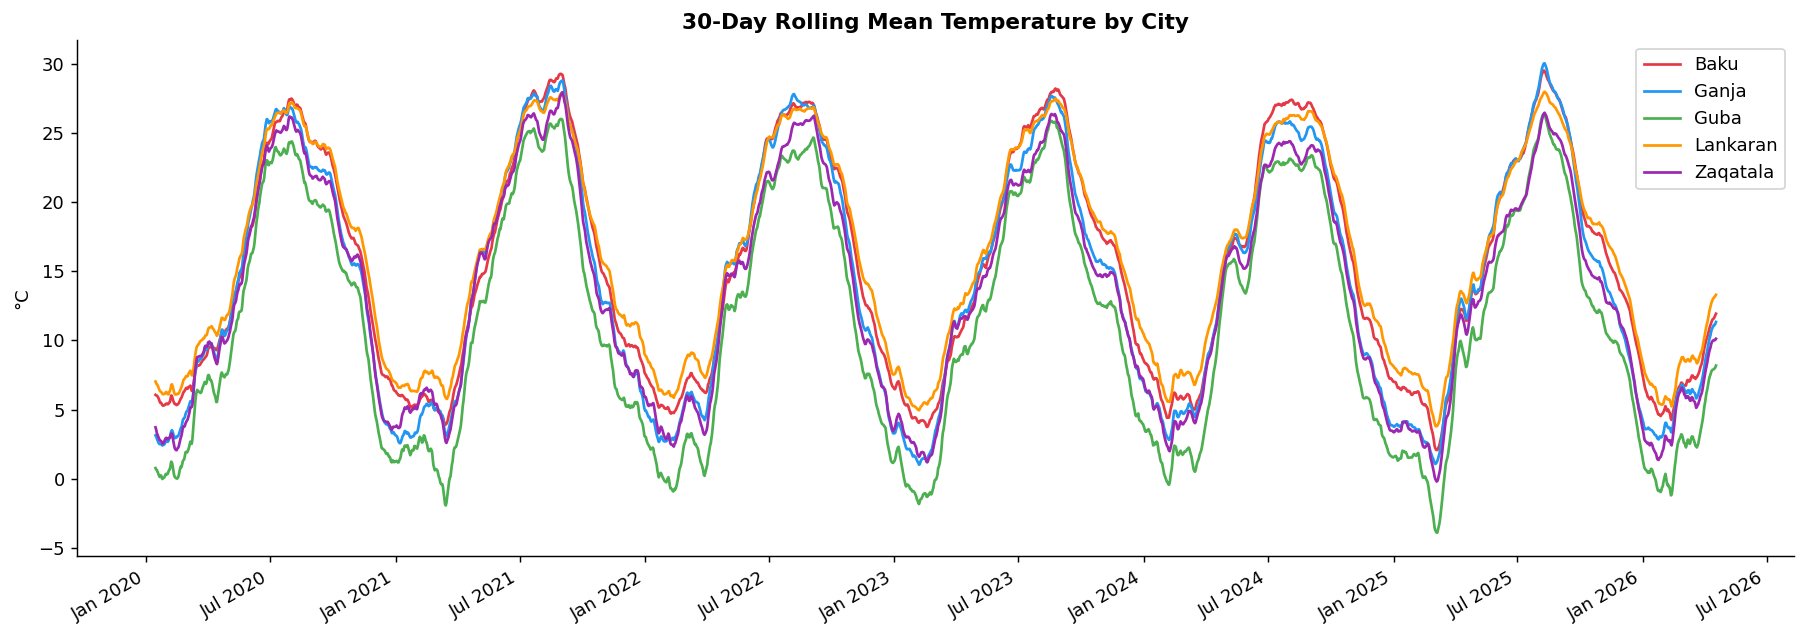

In [13]:
fig, ax = plt.subplots(figsize=(14, 5))

for city, color in CITY_PALETTE.items():
    sub = daily[daily['City'] == city].set_index('date').sort_index()
    roll = sub['temperature_2m_mean'].rolling('30D', min_periods=15).mean()
    ax.plot(roll.index, roll.values, color=color, lw=1.5, label=city)

ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')
ax.set_title('30-Day Rolling Mean Temperature by City')
ax.set_ylabel('°C')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Seasonal Patterns

### 5.1 Monthly climatology — key variables

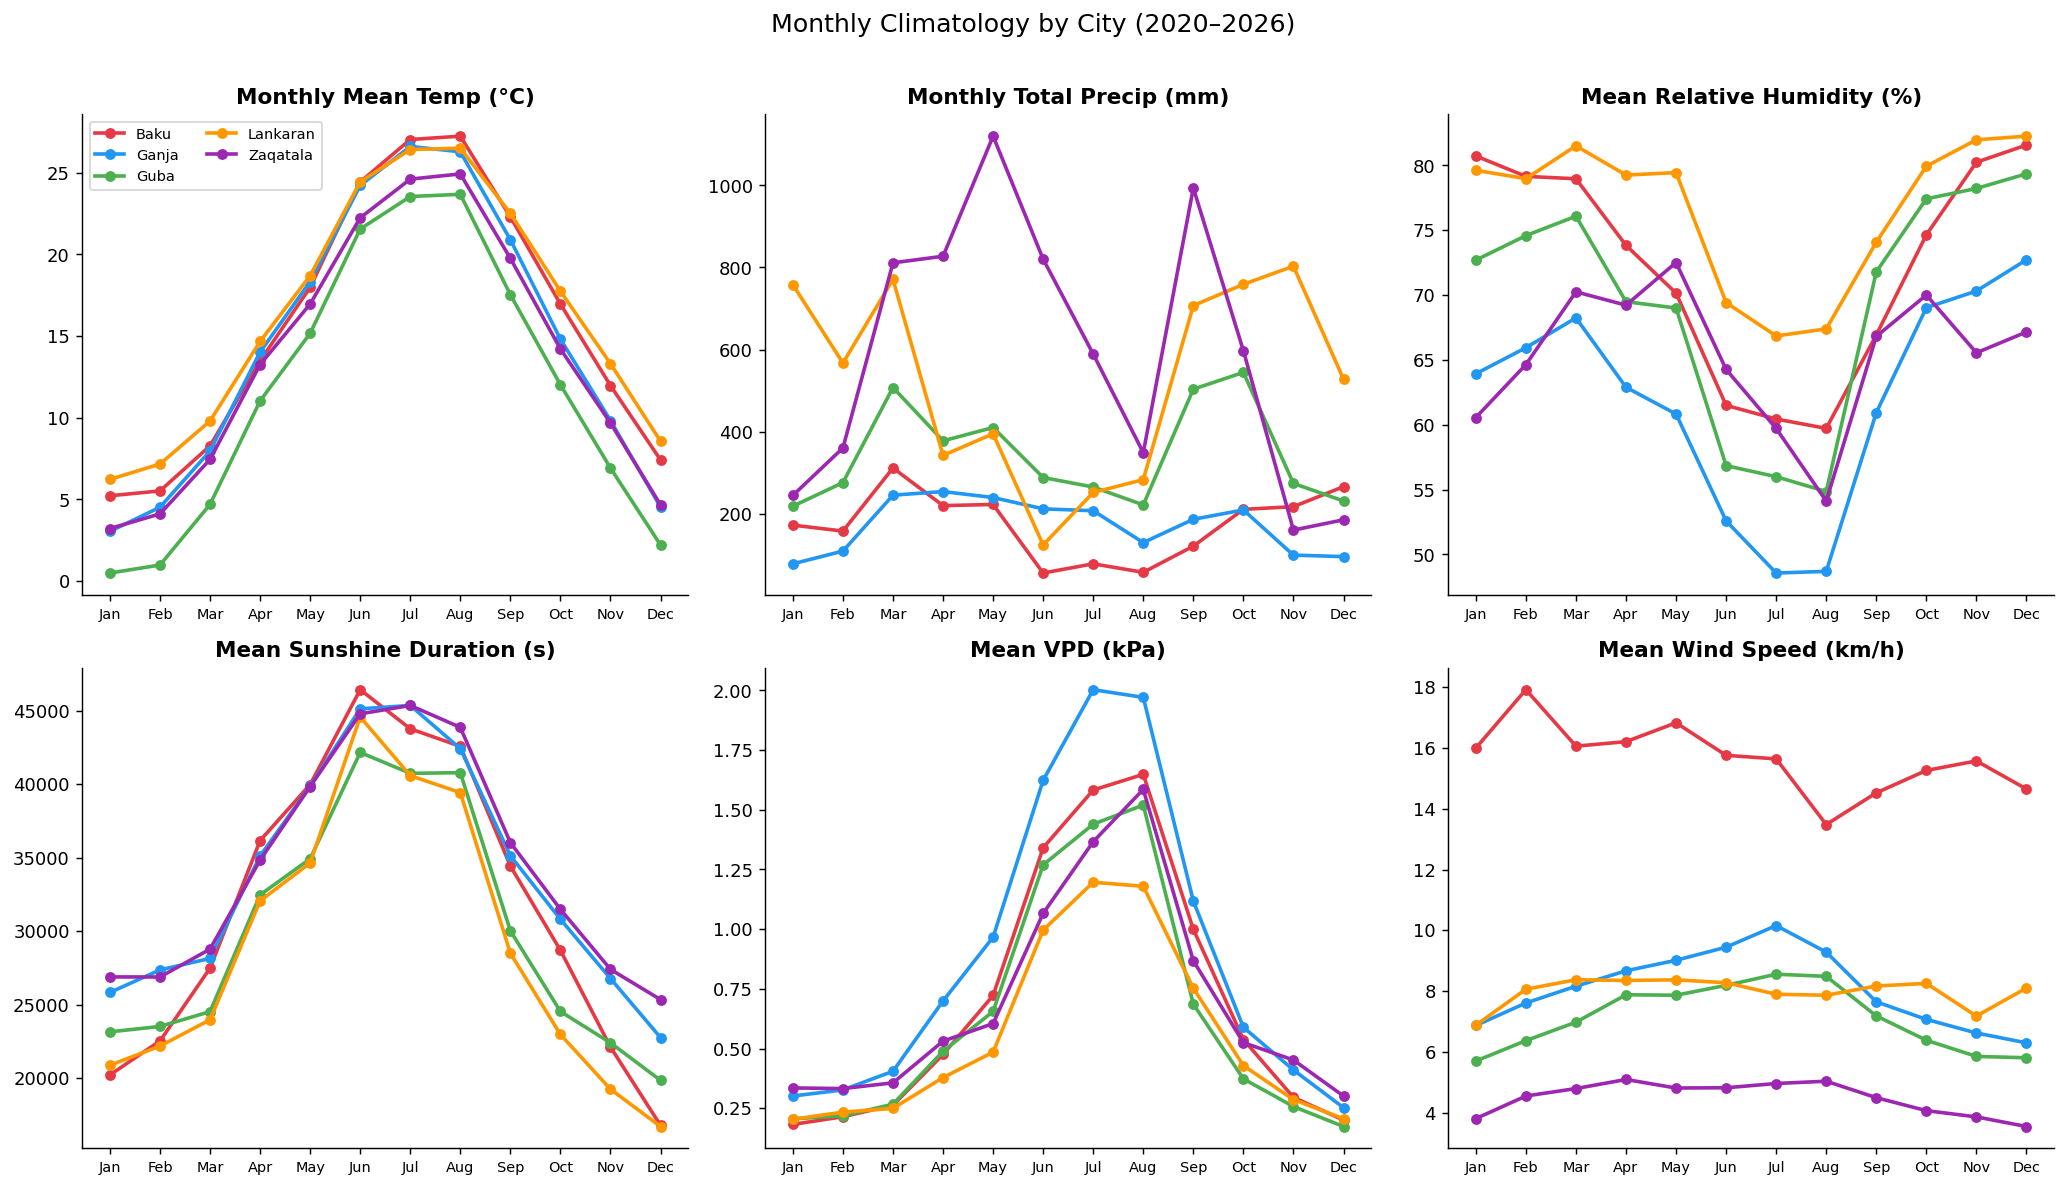

In [14]:
MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

monthly = daily.groupby(['City', 'month']).agg(
    temp_mean=('temperature_2m_mean', 'mean'),
    temp_std =('temperature_2m_mean', 'std'),
    precip   =('precipitation_sum',   'sum'),
    humidity =('relative_humidity_2m_mean', 'mean'),
    sunshine =('sunshine_duration_sum', 'mean'),
    vpd      =('vapour_pressure_deficit_mean', 'mean'),
    wind     =('wind_speed_10m_mean', 'mean'),
).reset_index()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

plot_cfg = [
    ('temp_mean',  'Monthly Mean Temp (°C)',       axes[0,0]),
    ('precip',     'Monthly Total Precip (mm)',    axes[0,1]),
    ('humidity',   'Mean Relative Humidity (%)',   axes[0,2]),
    ('sunshine',   'Mean Sunshine Duration (s)',   axes[1,0]),
    ('vpd',        'Mean VPD (kPa)',               axes[1,1]),
    ('wind',       'Mean Wind Speed (km/h)',       axes[1,2]),
]

for col, title, ax in plot_cfg:
    for city, color in CITY_PALETTE.items():
        sub = monthly[monthly['City'] == city]
        ax.plot(sub['month'], sub[col], 'o-', color=color, label=city, lw=2, ms=5)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MONTH_NAMES, fontsize=8)
    ax.set_title(title)

axes[0,0].legend(fontsize=8, ncol=2)
plt.suptitle('Monthly Climatology by City (2020–2026)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 5.2 Heatmap — monthly mean temperature per city

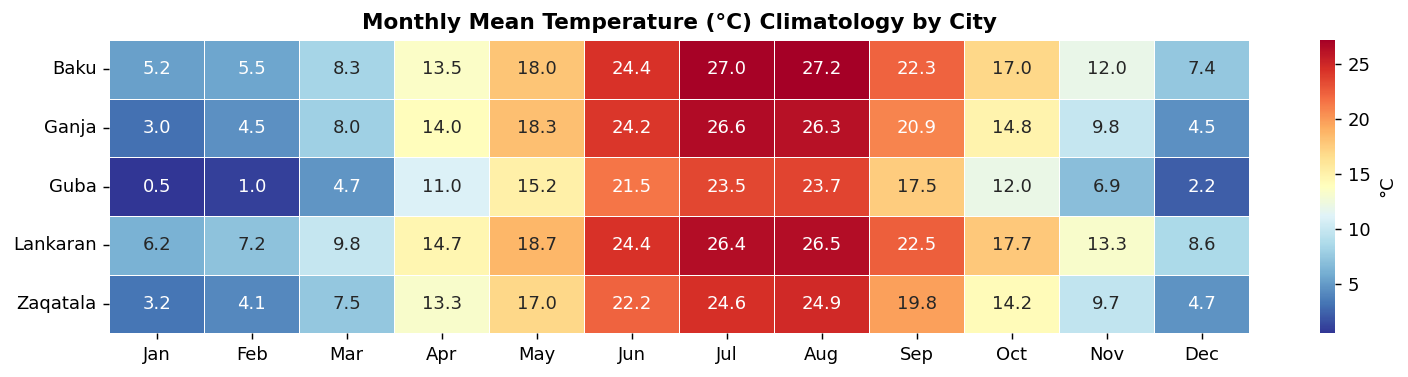

In [15]:
heat = daily.groupby(['City', 'month'])['temperature_2m_mean'].mean().unstack('month')
heat.columns = MONTH_NAMES

fig, ax = plt.subplots(figsize=(12, 3))
sns.heatmap(
    heat, annot=True, fmt='.1f', cmap='RdYlBu_r',
    linewidths=0.5, ax=ax, cbar_kws={'label': '°C'},
)
ax.set_title('Monthly Mean Temperature (°C) Climatology by City')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

### 5.3 Seasonal violin — temperature diurnal range

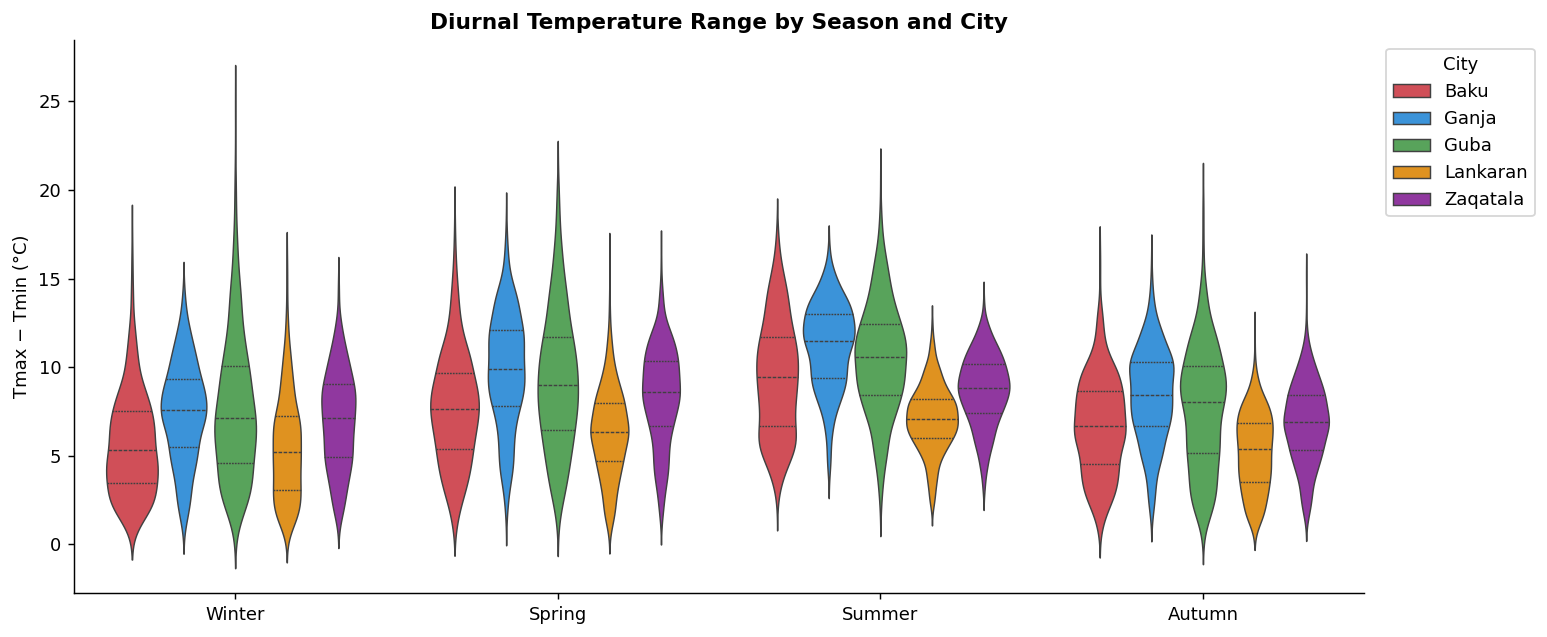

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.violinplot(
    data=daily, x='season', y='temp_range',
    hue='City', hue_order=CITIES,
    order=season_order, palette=CITY_PALETTE,
    inner='quartile', ax=ax, linewidth=0.8,
)
ax.set_title('Diurnal Temperature Range by Season and City')
ax.set_xlabel(''); ax.set_ylabel('Tmax − Tmin (°C)')
ax.legend(title='City', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 5.4 Day-of-year climatology — temperature envelope

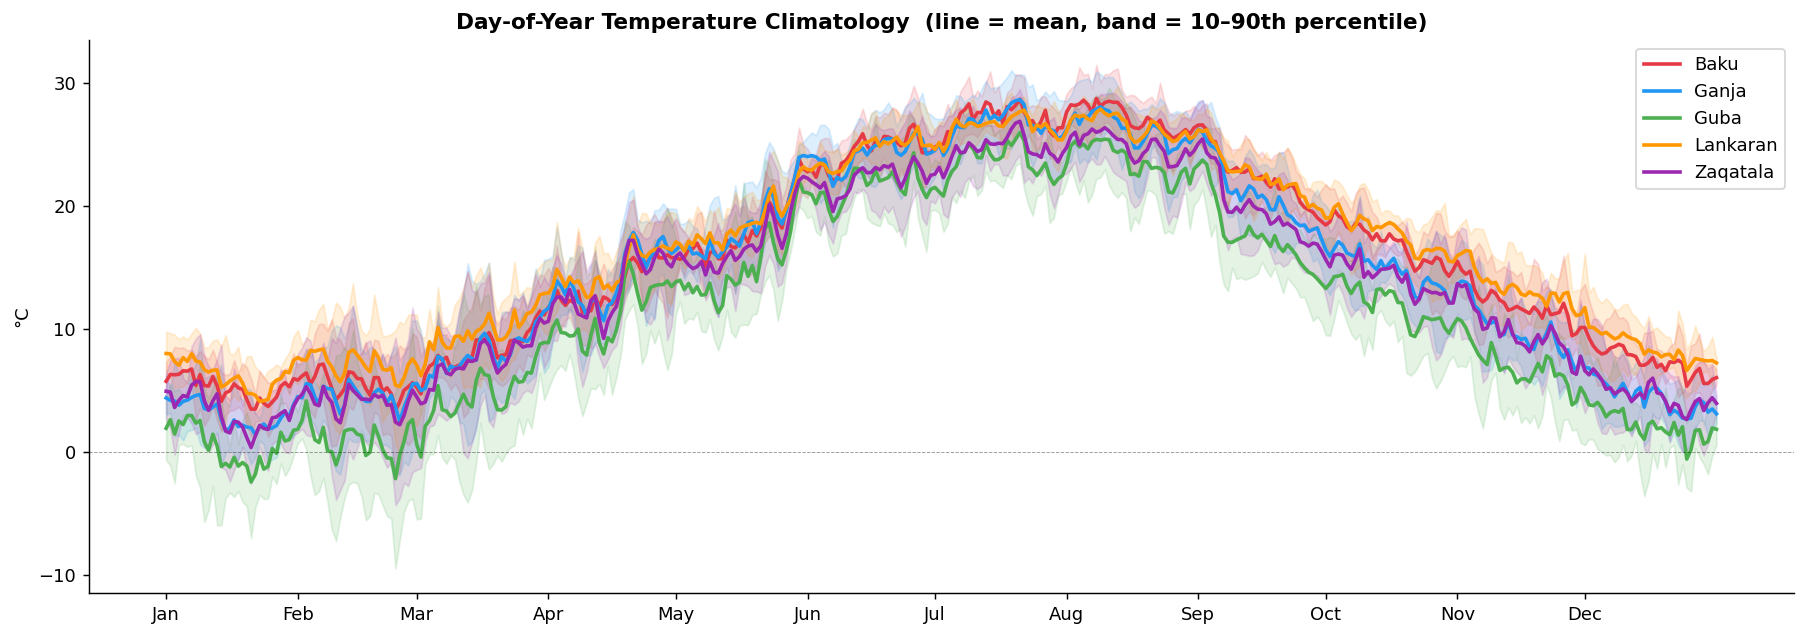

In [17]:
doy_clim = daily.groupby(['City', 'doy']).agg(
    t_mean=('temperature_2m_mean', 'mean'),
    t_p10 =('temperature_2m_mean', lambda x: np.percentile(x, 10)),
    t_p90 =('temperature_2m_mean', lambda x: np.percentile(x, 90)),
).reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
for city, color in CITY_PALETTE.items():
    sub = doy_clim[doy_clim['City'] == city]
    ax.fill_between(sub['doy'], sub['t_p10'], sub['t_p90'], color=color, alpha=0.15)
    ax.plot(sub['doy'], sub['t_mean'], color=color, lw=2, label=city)

ax.axhline(0, color='k', lw=0.5, ls='--', alpha=0.4)
month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
ax.set_xticks(month_starts)
ax.set_xticklabels(MONTH_NAMES)
ax.set_title('Day-of-Year Temperature Climatology  (line = mean, band = 10–90th percentile)')
ax.set_ylabel('°C'); ax.set_xlabel('')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Cross-City Comparison

### 6.1 Radar chart — city climate fingerprint

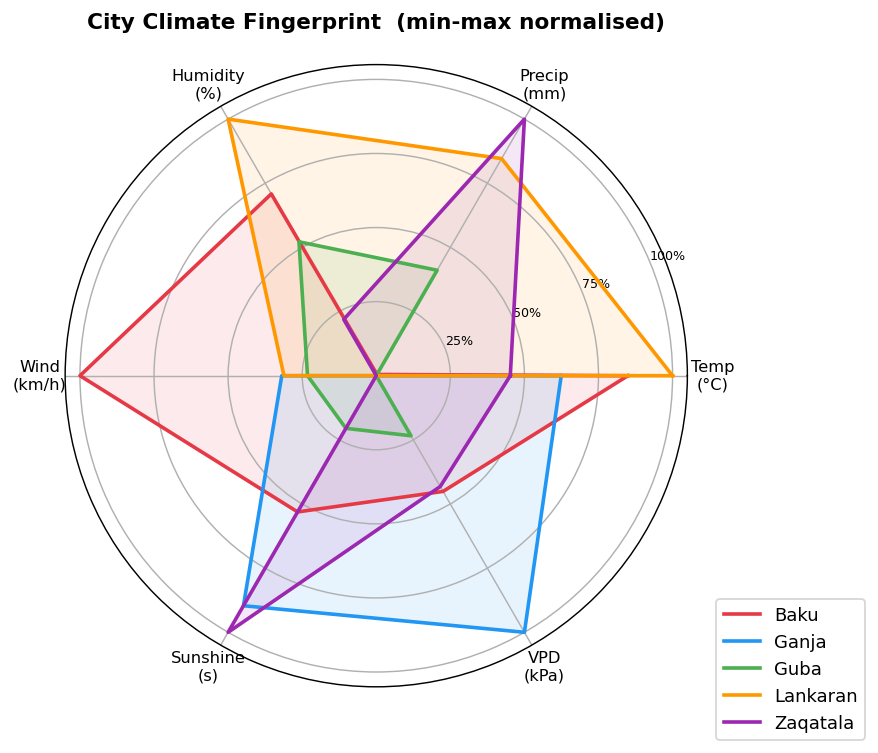

In [18]:
from matplotlib.patches import FancyArrowPatch

RADAR_VARS = [
    'temperature_2m_mean', 'precipitation_sum',
    'relative_humidity_2m_mean', 'wind_speed_10m_mean',
    'sunshine_duration_sum', 'vapour_pressure_deficit_mean',
]
RADAR_LABELS = ['Temp\n(°C)', 'Precip\n(mm)', 'Humidity\n(%)',
                'Wind\n(km/h)', 'Sunshine\n(s)', 'VPD\n(kPa)']

city_means = daily.groupby('City')[RADAR_VARS].mean()
# Min-max normalise to [0,1] per variable
normed = (city_means - city_means.min()) / (city_means.max() - city_means.min())

N = len(RADAR_VARS)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the loop

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'polar': True})

for city, color in CITY_PALETTE.items():
    vals = normed.loc[city].tolist() + normed.loc[city].tolist()[:1]
    ax.plot(angles, vals, color=color, lw=2, label=city)
    ax.fill(angles, vals, color=color, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(RADAR_LABELS, fontsize=9)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=7)
ax.set_title('City Climate Fingerprint  (min-max normalised)', pad=20)
ax.legend(loc='lower right', bbox_to_anchor=(1.3, -0.1))
plt.tight_layout()
plt.show()

### 6.2 Mean annual stats table with z-score ranking

In [19]:
summary_tbl = daily.groupby('City')[RADAR_VARS].mean().round(2)
summary_tbl.columns = ['Temp (°C)', 'Precip (mm/day)', 'Humidity (%)',
                        'Wind (km/h)', 'Sunshine (s)', 'VPD (kPa)']
print('Mean annual statistics by city')
summary_tbl

Mean annual statistics by city


,Temp (°C),Precip (mm/day),Humidity (%),Wind (km/h),Sunshine (s),VPD (kPa)
City,,,,,,
Baku,15.320,0.910,72.590,15.690,31502.560,0.690
Ganja,14.260,0.900,62.190,8.050,33499.490,0.870
Guba,11.320,1.790,69.850,7.080,29722.840,0.620
Lankaran,16.020,2.730,76.870,7.970,28602.150,0.540
Zaqatala,13.450,3.070,65.410,4.480,34065.140,0.680


### 6.3 Pairwise correlation heatmap

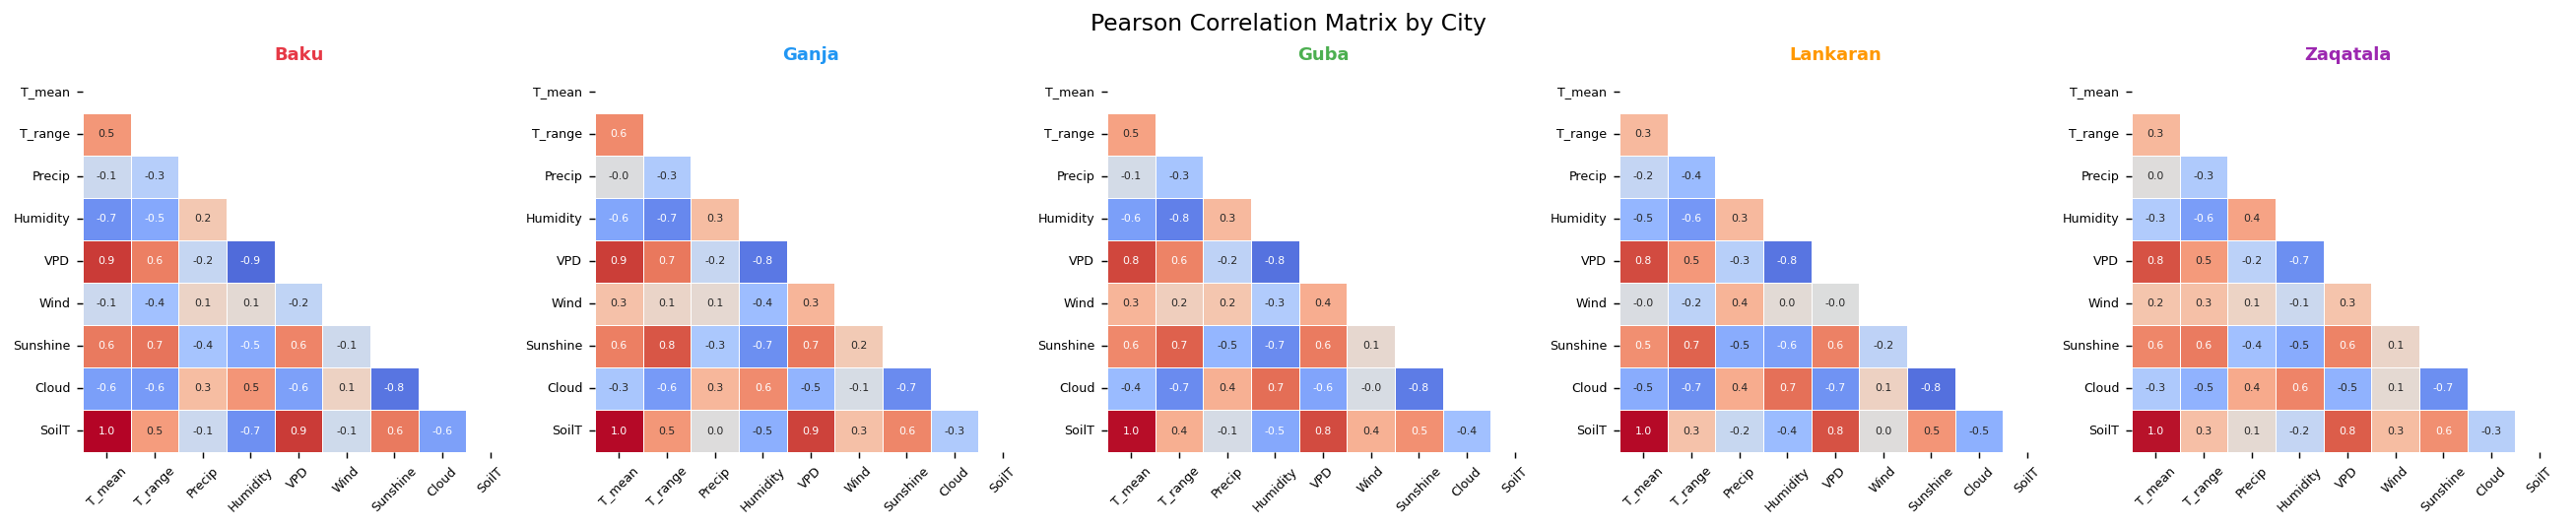

In [20]:
CORR_VARS = [
    'temperature_2m_mean', 'temp_range', 'precipitation_sum',
    'relative_humidity_2m_mean', 'vapour_pressure_deficit_mean',
    'wind_speed_10m_mean', 'sunshine_duration_sum',
    'cloud_cover_mean', 'soil_temperature_0_to_7cm_mean',
]
SHORT_NAMES = [
    'T_mean', 'T_range', 'Precip', 'Humidity', 'VPD',
    'Wind', 'Sunshine', 'Cloud', 'SoilT',
]

fig, axes = plt.subplots(1, len(CITIES), figsize=(4 * len(CITIES), 4),
                          constrained_layout=True)

for ax, city in zip(axes, CITIES):
    sub = daily[daily['City'] == city][CORR_VARS].copy()
    sub.columns = SHORT_NAMES
    corr = sub.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(
        corr, mask=mask, annot=True, fmt='.1f', cmap='coolwarm',
        vmin=-1, vmax=1, linewidths=0.3, ax=ax,
        annot_kws={'size': 6}, cbar=False,
    )
    ax.set_title(city, fontsize=10, color=CITY_PALETTE[city], fontweight='bold')
    ax.tick_params(axis='x', labelsize=7, rotation=45)
    ax.tick_params(axis='y', labelsize=7)

plt.suptitle('Pearson Correlation Matrix by City', fontsize=13)
plt.show()

### 6.4 Extreme event frequency by city

In [21]:
extremes = {}
for city in CITIES:
    sub = daily[daily['City'] == city]
    n = len(sub)
    extremes[city] = {
        'Hot days (Tmax > 35°C)'        : (sub['temperature_2m_max'] > 35).sum(),
        'Frost days (Tmin < 0°C)'       : (sub['temperature_2m_min'] < 0).sum(),
        'Heavy rain (> 20 mm/day)'      : (sub['precipitation_sum'] > 20).sum(),
        'Dry days (precip = 0)'         : (sub['precipitation_sum'] == 0).sum(),
        'Strong wind (gust > 50 km/h)'  : (sub['wind_gusts_10m_max'] > 50).sum(),
        'Full cloud (> 90%)'            : (sub['cloud_cover_mean'] > 90).sum(),
    }

ext_df = pd.DataFrame(extremes).T
print('Extreme event day counts (2020–2026)')
ext_df

Extreme event day counts (2020–2026)


,Hot days (Tmax > 35°C),Frost days (Tmin < 0°C),Heavy rain (> 20 mm/day),Dry days (precip = 0),Strong wind (gust > 50 km/h),Full cloud (> 90%)
Baku,80,85,9,1502,771,410
Ganja,98,295,9,1479,218,274
Guba,33,569,23,1214,53,538
Lankaran,2,44,78,1277,60,559
Zaqatala,6,289,92,1280,20,293


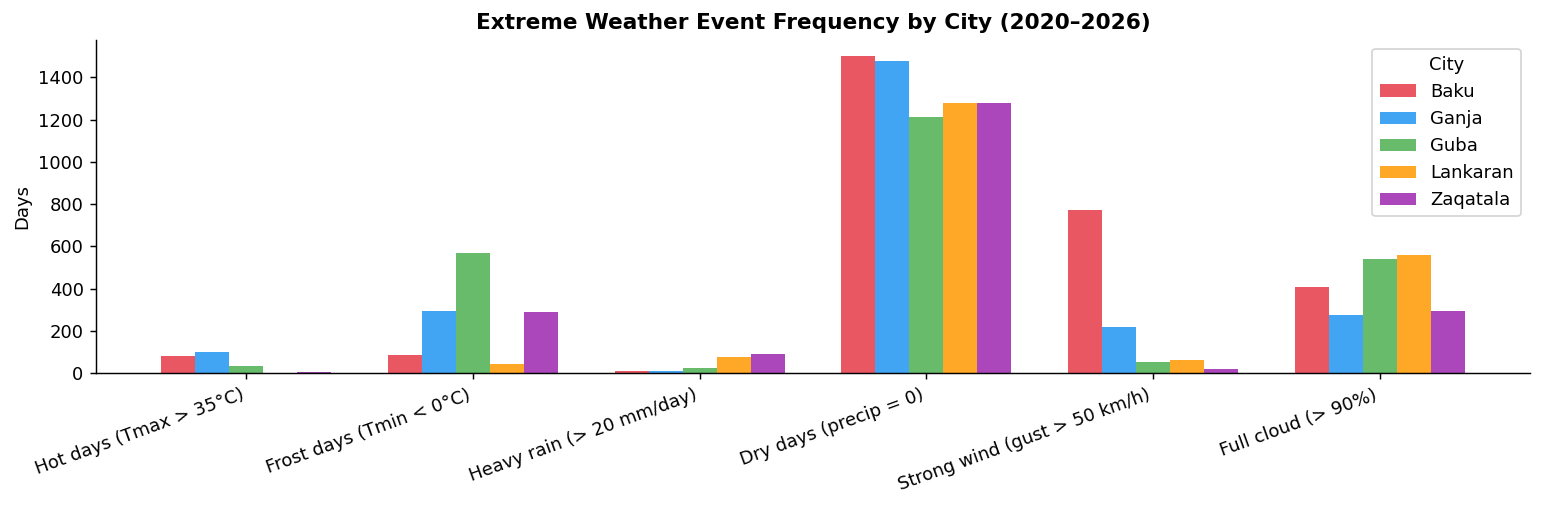

In [22]:
fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(len(ext_df.columns))
w = 0.15
for i, (city, color) in enumerate(CITY_PALETTE.items()):
    ax.bar(x + i * w, ext_df.loc[city], w, label=city, color=color, alpha=0.85)
ax.set_xticks(x + w * 2)
ax.set_xticklabels(ext_df.columns, rotation=20, ha='right')
ax.set_ylabel('Days')
ax.set_title('Extreme Weather Event Frequency by City (2020–2026)')
ax.legend(title='City')
plt.tight_layout()
plt.show()

## 7. NDVI — Vegetation Index Patterns

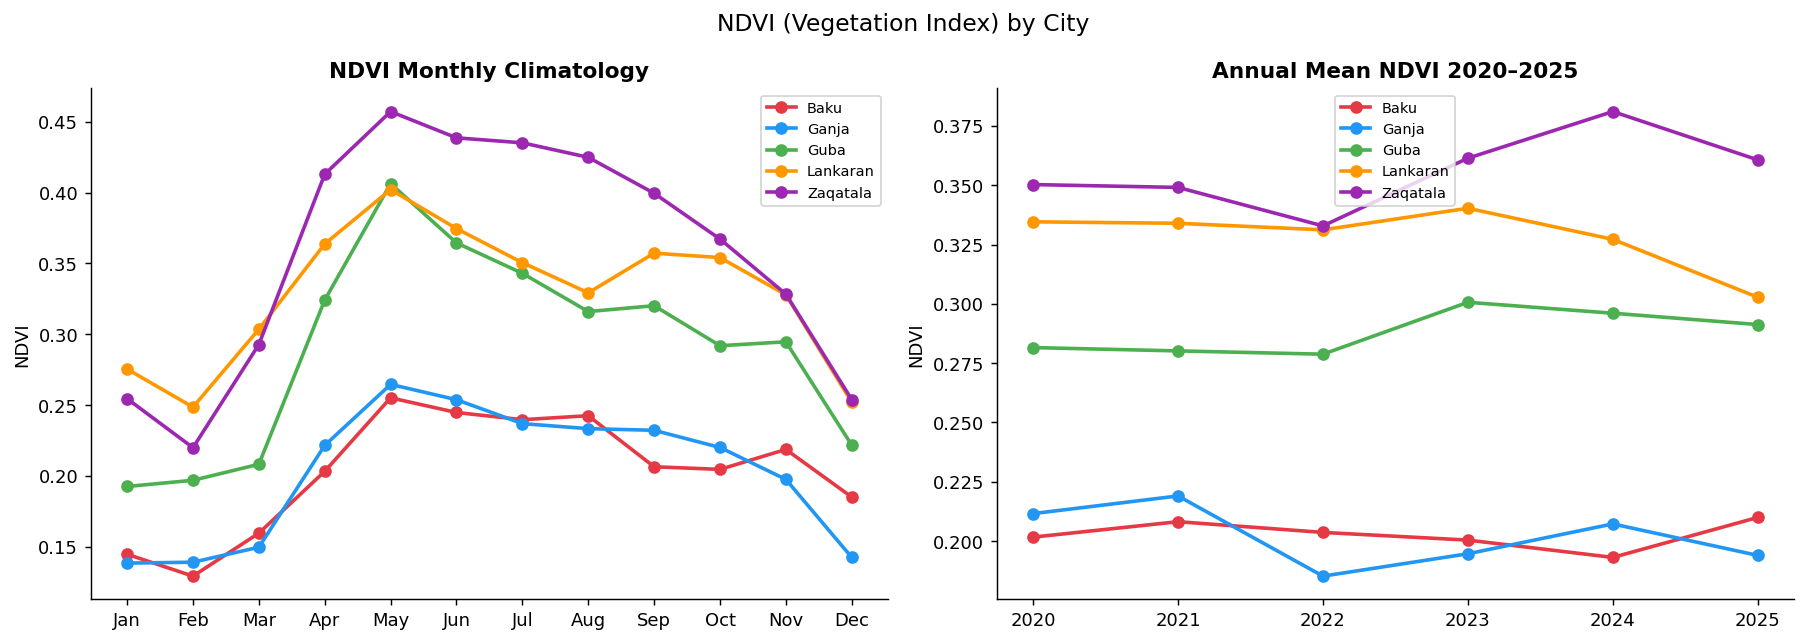


NDVI descriptive stats (5 cities):


,count,mean,std,min,25%,50%,75%,max
City,,,,,,,,
Baku,144.000,0.200,0.055,0.011,0.158,0.209,0.237,0.306
Ganja,144.000,0.199,0.053,0.009,0.153,0.209,0.241,0.339
Guba,144.000,0.286,0.088,0.006,0.217,0.297,0.350,0.507
Lankaran,144.000,0.325,0.077,-0.005,0.281,0.330,0.359,0.584
Zaqatala,144.000,0.353,0.097,0.002,0.268,0.362,0.426,0.528


In [23]:
# Focus on the 5 study cities present in weather data
ndvi5 = ndvi[ndvi['City'].isin(CITIES)].copy()
ndvi5['month'] = ndvi5['date'].dt.month
ndvi5['year']  = ndvi5['date'].dt.year

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monthly climatology
ax = axes[0]
ndvi_mo = ndvi5.groupby(['City','month'])['NDVI'].mean().reset_index()
for city, color in CITY_PALETTE.items():
    sub = ndvi_mo[ndvi_mo['City'] == city]
    ax.plot(sub['month'], sub['NDVI'], 'o-', color=color, label=city, lw=2)
ax.set_xticks(range(1,13)); ax.set_xticklabels(MONTH_NAMES)
ax.set_title('NDVI Monthly Climatology')
ax.set_ylabel('NDVI'); ax.legend(fontsize=8)

# Annual trend
ax = axes[1]
ndvi_yr = ndvi5[ndvi5['year'] < 2026].groupby(['City','year'])['NDVI'].mean().reset_index()
for city, color in CITY_PALETTE.items():
    sub = ndvi_yr[ndvi_yr['City'] == city]
    ax.plot(sub['year'], sub['NDVI'], 'o-', color=color, label=city, lw=2)
ax.set_title('Annual Mean NDVI 2020–2025')
ax.set_ylabel('NDVI'); ax.legend(fontsize=8)

plt.suptitle('NDVI (Vegetation Index) by City', fontsize=13)
plt.tight_layout(); plt.show()

print('\nNDVI descriptive stats (5 cities):')
ndvi5.groupby('City')['NDVI'].describe().round(3)

## 8. Wildfire (FIRMS) & Lightning Patterns

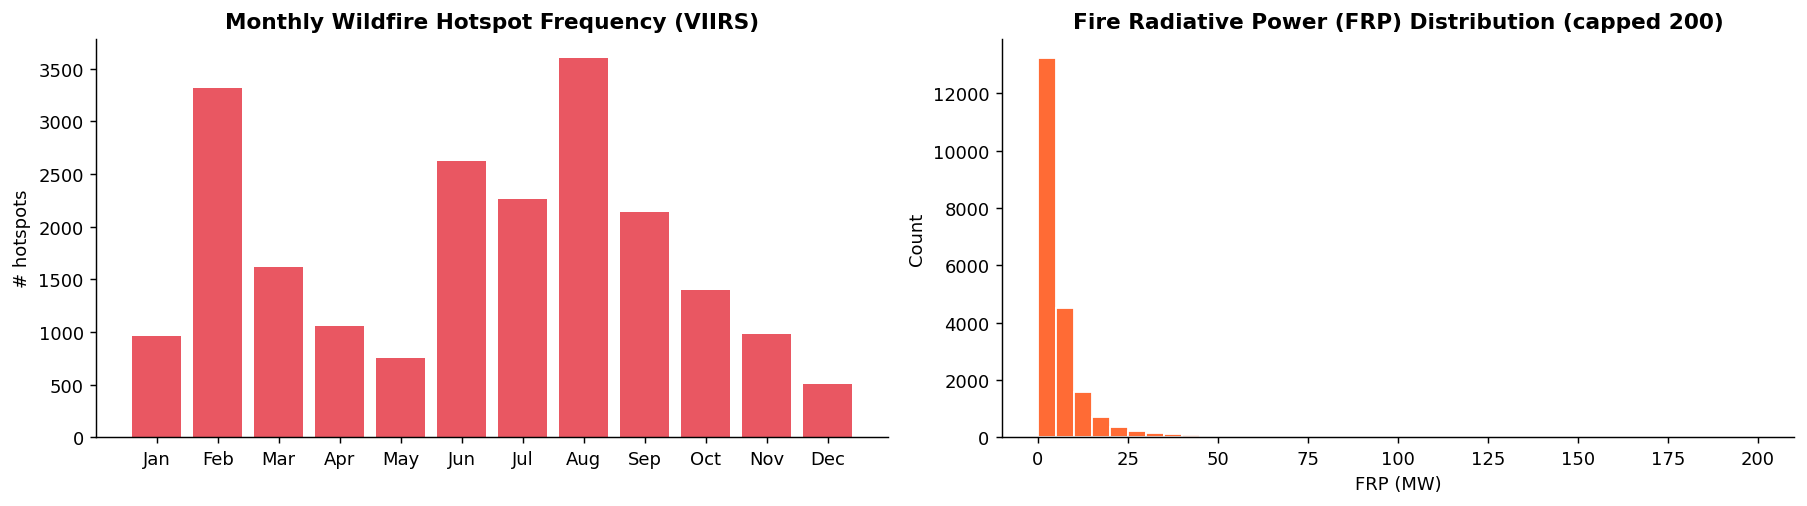

FIRMS summary:
            frp  bright_ti4
count 21218.000   21218.000
mean      6.720     330.450
std      11.400      18.790
min       0.060     208.000
25%       1.690     313.600
50%       3.650     333.780
75%       7.310     342.730
max     355.470     367.000


In [24]:
firms['month'] = firms['acq_date'].dt.month
firms['year']  = firms['acq_date'].dt.year

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Monthly fire count
ax = axes[0]
mo_fires = firms.groupby('month').size().reset_index(name='count')
ax.bar(mo_fires['month'], mo_fires['count'], color='#E63946', alpha=0.85)
ax.set_xticks(range(1,13)); ax.set_xticklabels(MONTH_NAMES)
ax.set_title('Monthly Wildfire Hotspot Frequency (VIIRS)')
ax.set_ylabel('# hotspots')

# FRP distribution
ax = axes[1]
ax.hist(firms['frp'].clip(upper=200), bins=40, color='#FF6B35', edgecolor='white')
ax.set_title('Fire Radiative Power (FRP) Distribution (capped 200)')
ax.set_xlabel('FRP (MW)'); ax.set_ylabel('Count')

plt.tight_layout(); plt.show()

print('FIRMS summary:')
print(firms[['frp','bright_ti4','confidence']].describe().round(2))

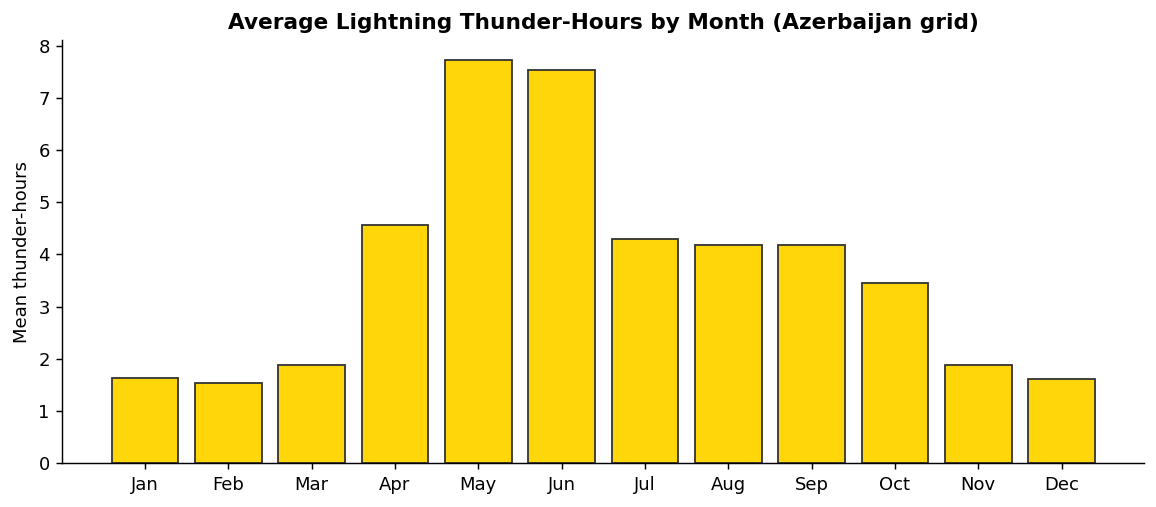

In [25]:
# Lightning monthly pattern
lig_monthly = lightning.groupby('month')['thunder_hours'].mean().reset_index()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(lig_monthly['month'], lig_monthly['thunder_hours'], color='#FFD60A', edgecolor='#333')
ax.set_xticks(range(1,13)); ax.set_xticklabels(MONTH_NAMES)
ax.set_title('Average Lightning Thunder-Hours by Month (Azerbaijan grid)')
ax.set_ylabel('Mean thunder-hours')
plt.tight_layout(); plt.show()

## 9. Pattern Discovery — Candidates for Formal Statistical Tests

### 9.1 Kruskal-Wallis: do cities differ significantly in temperature?

In [26]:
print('Kruskal-Wallis H-test — does mean temperature differ across cities?')
groups = [daily.loc[daily['City'] == c, 'temperature_2m_mean'].dropna().values
          for c in CITIES]
H, p = kruskal(*groups)
print(f'  H = {H:.2f},  p = {p:.2e}  → {"Significant" if p < 0.05 else "Not significant"} at α=0.05')

print('\nKruskal-Wallis — does precipitation differ across cities?')
groups_p = [daily.loc[daily['City'] == c, 'precipitation_sum'].dropna().values
            for c in CITIES]
H2, p2 = kruskal(*groups_p)
print(f'  H = {H2:.2f},  p = {p2:.2e}  → {"Significant" if p2 < 0.05 else "Not significant"} at α=0.05')

Kruskal-Wallis H-test — does mean temperature differ across cities?
  H = 372.46,  p = 2.48e-79  → Significant at α=0.05

Kruskal-Wallis — does precipitation differ across cities?
  H = 210.86,  p = 1.74e-44  → Significant at α=0.05


### 9.2 Spearman correlations — VPD & NDVI (wildfire relevance)

In [27]:
# Merge daily weather with NDVI for 5 cities
daily_month = daily[['City','date','vapour_pressure_deficit_mean','temperature_2m_max',
                      'precipitation_sum']].copy()
daily_month['month'] = daily_month['date'].dt.month
daily_month['year']  = daily_month['date'].dt.year
dm_agg = daily_month.groupby(['City','year','month']).agg(
    vpd=('vapour_pressure_deficit_mean','mean'),
    tmax=('temperature_2m_max','mean'),
    precip=('precipitation_sum','sum')
).reset_index()

ndvi5['year']  = ndvi5['date'].dt.year
ndvi5['month'] = ndvi5['date'].dt.month
ndvi_mo2 = ndvi5.groupby(['City','year','month'])['NDVI'].mean().reset_index()

merged = dm_agg.merge(ndvi_mo2, on=['City','year','month'], how='inner')

print('Spearman correlations with NDVI (pooled all cities)')
for col in ['vpd', 'tmax', 'precip']:
    r, p = spearmanr(merged[col].dropna(), merged['NDVI'][merged[col].notna()])
    print(f'  NDVI ~ {col:<8}  ρ = {r:+.3f},  p = {p:.2e}')

Spearman correlations with NDVI (pooled all cities)
  NDVI ~ vpd       ρ = +0.400,  p = 8.24e-16
  NDVI ~ tmax      ρ = +0.470,  p = 5.59e-22
  NDVI ~ precip    ρ = +0.428,  p = 4.00e-18


### 9.3 Scatter matrix — fire weather index proxies

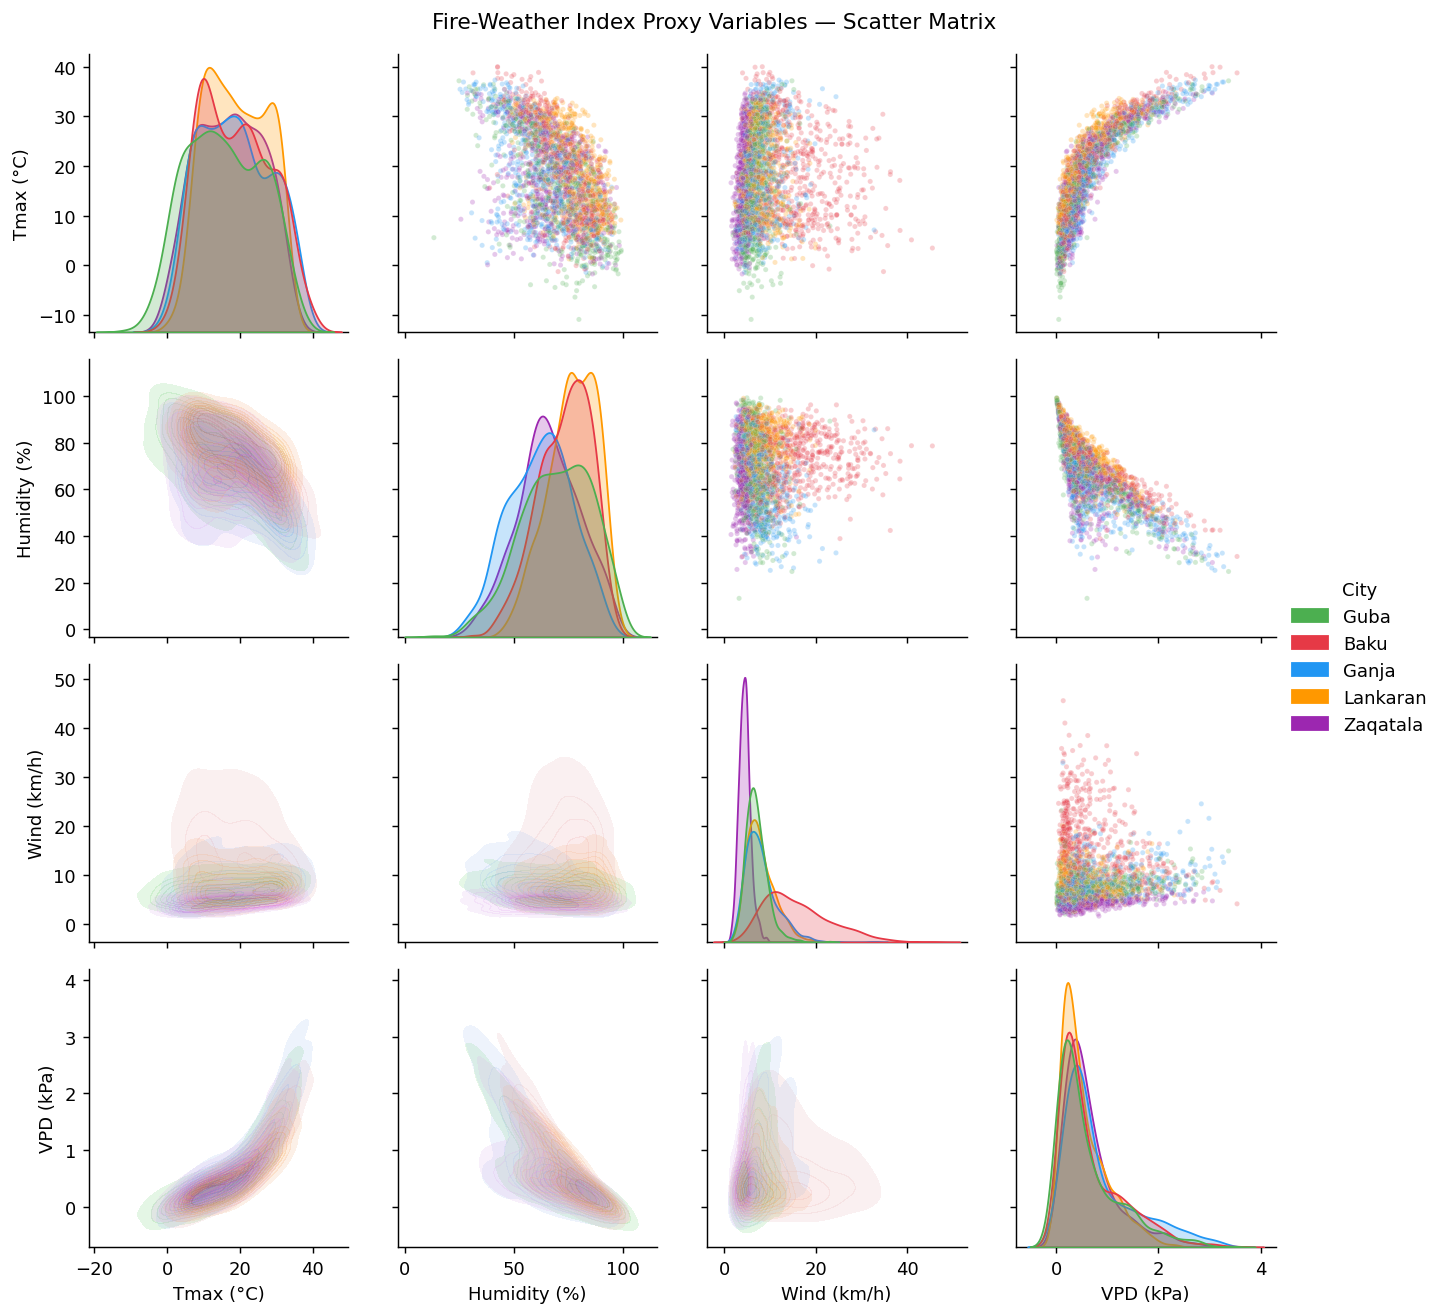

In [28]:
fwi_cols = ['temperature_2m_max', 'relative_humidity_2m_mean',
            'wind_speed_10m_mean', 'vapour_pressure_deficit_mean']
fwi_labels = ['Tmax (°C)', 'Humidity (%)', 'Wind (km/h)', 'VPD (kPa)']

# Sample for speed
plot_data = daily[fwi_cols + ['City']].dropna().sample(n=3000, random_state=42)
plot_data.columns = fwi_labels + ['City']

g = sns.PairGrid(plot_data, vars=fwi_labels, hue='City', palette=CITY_PALETTE,
                  diag_sharey=False, height=2.5)
g.map_upper(sns.scatterplot, alpha=0.25, s=8)
g.map_lower(sns.kdeplot, fill=True, alpha=0.2)
g.map_diag(sns.kdeplot, fill=True)
g.add_legend(title='City')
g.figure.suptitle('Fire-Weather Index Proxy Variables — Scatter Matrix', y=1.01)
plt.show()